IMT 2200 - Introducción a Ciencia de Datos<br>
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

---

## Tarea 01 – Cargando y Analizando Datos

- **Fecha de Entrega:** martes 26 de agosto de 2025, a las 23:59.
- 
**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en l emódulo de Tara 01 habilitado en Canvas.




## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, tendremos como objetivo comprender cómo han cambiado los juegos de mesa en los últimos 40 años. Específicamente queremos saber qué tipos de juegos se han vuelto más comunes hoy en día y qué los caracteriza.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las vualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

Estaremos utilizando información extraída desde [BoardGameGeek.com](https://boardgamegeek.com/), una plataforma para aficionados de los juegos de mesa, que permite a sus usuarios regtrar, calificar e intercambiar sus juegos favoritos. Actualmente, BGG es una de las bases de datos más extensa y diversa de juegos de mesa.

El dataset con el que trabajaremos conste en un grupo de archivos CSV que contienen información sobre más de 100.000 juegos de mesa almacenados en la plataforma. Este puede descargarse directamente desde el siguiente enlace: https://www.kaggle.com/datasets/mshepherd/board-games Para descargar los datos, haga click en el botón de **Download**, donde podrá descargar los archivos como `.zip`, o bien utilizar la API de Kaggle.

Para el desarrollo de esta tarea, solo utilizaremos los archivos con el prefijo `bgg_`.

**Si utiliza la API de Kaggle para descargar los datos, deje el código utilizado en la siguiente celda:**

In [2]:
# Descarga de datos desde Kaggle

### 2.1 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 DataFrame unificado (1 punto)

Vamos a cargar en un DataFrame los datos de juegos guardados en el documento `bgg_GameItem.csv`. Al inspeccionar nuestros datos, podemos notar que los valores de ciertas comunas vienen "codificados" con ID. Para comenzar, vamos a juntar la información de los dtintos archivos descargados.

**a) (0.8 pts)** Genere un DataFrame único con toda la información de cada juego, incluyendo: nombres de arttas y deñadores involucrados, mecánicas, categorías, tipo, familia y editorial. Guarde este DataFrame en un nuevo archivo CSV.

In [4]:
#Primero pasamos todos los archivos a DataFrame
df_principal = pd.read_csv("Data/bgg_GameItem.csv")
df_person = pd.read_csv("Data/bgg_Person.csv")
df_mechanic = pd.read_csv("Data/bgg_Mechanic.csv")
df_category = pd.read_csv("Data/bgg_Category.csv")
df_type = pd.read_csv("Data/bgg_GameType.csv")
df_family = pd.read_csv("Data/bgg_GameFamily.csv")
df_publisher = pd.read_csv("Data/bgg_Publisher.csv")

#Luego antes de unir los DataFrames a uno solo, tuve que arreglar un error que me aparecia al querer unirlos, ya que estamos trabajando con datos int y str
#por lo cual, le pregunte a una IA como podia solucionar el error de los diferentes tipos
# de datos y me dijo que ocupara la funcion pd.to_numeric y el errors="coerce", el cual me ayuda a resolver el problema ya que convierte un argumente a tipo numerico
#y con coerce cuando no sea valido lo establecera como NaN que es como si no hubiera nada. 
#Por último ocupamos el astype(int64) para que queden como números enteros.
for columna in ['game_type', 'designer', 'artist', 'publisher', 'category', 'mechanic', 'family']:
    df_principal[columna] = pd.to_numeric(df_principal[columna], errors='coerce').astype("Int64")


#Luego al hacer las uniones de los DataFrame me percate que el archivo de diseñador y artistas me daban error ya que vienen en un mismo archivo y por ende 
# tenian mismos nombres y pandas les agregaba los sufijos x e y, y al hacer eso se me generaron problemas con las otros archivos, así que decidí cambiarlo todo
#Ocupe la función rename, ya que era la cual me permitía hacer ese cambio, y cree dos nuevos dataframe que es person_designer y person_artist ya que eran las que
#anteriormente no existian porque estaban unidas
df_person_designer = df_person.rename(columns={'bgg_id': 'id_designer', 'name': 'designer_'})
df_person_artist = df_person.rename(columns={'bgg_id': 'id_artist', 'name': 'artist_'})
df_mechanic = df_mechanic.rename(columns={'bgg_id': 'id_mechanic', 'name': 'mechanic_'})
df_category = df_category.rename(columns={'bgg_id': 'id_category', 'name': 'category_'})
df_type = df_type.rename(columns={'bgg_id': 'id_gametype', 'name': 'gametype_'})
df_family = df_family.rename(columns={'bgg_id': 'id_family', 'name': 'family_'})
df_publisher = df_publisher.rename(columns={'bgg_id': 'id_publisher', 'name': 'publisher_'})

#Luego realice las uniones de los DataFrames uno a uno, a través de la función merge() ya que me permitía unir varios y dejarlos en uno solo, que es lo que se me pide.
df_unificado = pd.merge(df_principal, df_type, left_on='game_type', right_on='id_gametype', how='left')
df_unificado = pd.merge(df_unificado, df_person_designer, left_on='designer', right_on='id_designer', how='left')
df_unificado = pd.merge(df_unificado, df_person_artist, left_on='artist', right_on='id_artist', how='left')
df_unificado = pd.merge(df_unificado, df_mechanic, left_on='mechanic', right_on='id_mechanic', how='left')
df_unificado = pd.merge(df_unificado, df_category, left_on='category', right_on='id_category', how='left')
df_unificado = pd.merge(df_unificado, df_family, left_on='family', right_on='id_family', how='left')
df_unificado = pd.merge(df_unificado, df_publisher, left_on='publisher', right_on='id_publisher', how='left')

#Luego, como ya tenemos en el DataFrame los valores que no se encuentran codificados, eliminamos los que siguen codificados, a través de la función drop()
df_unificado= df_unificado.drop(columns=[
    'game_type', 'designer', 'artist', 'mechanic', 'category', 'family', 'publisher',
    'id_gametype', 'id_designer', 'id_artist', 'id_mechanic', 'id_category', 'id_family', 'id_publisher'
])
#No me gustaba que el nombre de las columnas terminaran con el guión bajo entonces volvi a ocupar la función rename y les cambie el nombre
# a su nombre original correspondiente.

df_unificado = df_unificado.rename(columns={
    'gametype_': 'game_type', 'designer_': 'designer', 'artist_': 'artist',
    'mechanic_': 'mechanic', 'category_': 'category', 'family_': 'family',
    'publisher_': 'publisher'
})


#Por último pasamos el DataFrame unificado a csv
df_unificado.to_csv('Data/data_unificado.csv', index=False)
df_unificado

,bgg_id,name,year,min_players,max_players,min_players_rec,max_players_rec,min_players_best,max_players_best,min_age,...,spielen_id,wikidata_id,wikipedia_id,game_type,designer,artist,mechanic,category,family,publisher
0,1,Die Macher,1986.0,3.0,5.0,4.0,5.0,5.0,5.0,14.0,...,NaN,NaN,NaN,Strategy Game,Karl-Heinz Schmiel,NaN,NaN,NaN,NaN,NaN
1,2,Dragonmaster,1981.0,3.0,4.0,3.0,4.0,3.0,4.0,12.0,...,NaN,NaN,NaN,Strategy Game,"G. W. ""Jerry"" D'Arcey",Bob Pepper,Trick-taking,NaN,NaN,NaN
2,3,Samurai,1998.0,2.0,4.0,2.0,4.0,3.0,3.0,10.0,...,NaN,NaN,NaN,Strategy Game,Reiner Knizia,Franz Vohwinkel,NaN,NaN,NaN,NaN
3,4,Tal der Könige,1992.0,2.0,4.0,2.0,4.0,2.0,4.0,12.0,...,NaN,NaN,NaN,Strategy Game,Christian Beierer,Thomas di Paolo,NaN,Ancient,NaN,KOSMOS
4,5,Acquire,1964.0,2.0,6.0,3.0,6.0,4.0,4.0,12.0,...,NaN,NaN,NaN,Strategy Game,Sid Sackson,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113899,391565,Champions!,2023.0,3.0,8.0,3.0,8.0,3.0,8.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Voting,Party Game,NaN,NaN
113900,391715,Leitin að stjörnunni,2022.0,2.0,20.0,2.0,20.0,2.0,20.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pb box ehf.
113901,391720,The String Railway Collection,2024.0,2.0,5.0,2.0,5.0,2.0,5.0,10.0,...,NaN,NaN,NaN,NaN,Hisashi Hayashi,Archie Edwards,NaN,NaN,Components: String,Play For Keeps
113902,391834,SpellBook,2023.0,1.0,4.0,1.0,4.0,1.0,4.0,12.0,...,NaN,NaN,NaN,NaN,Phil Walker-Harding,Cyrille Bertin,NaN,Fantasy,Admin: Upcoming Releases,Space Cowboys


**b) (0.2 pts)** ¿Cuánto espacio en disco ocupa este DataFrame? ¿Cuánto espacio en disco ocupan los documentos CSV separados? ¿A qué se debe esta diferencia? Comente.



El DataFrame creado recientemente ocupa 17.455 KB y por separado los documentos sumados en total ocupan 17.593 KB. Pesa menos el DataFrame unificado ya qye al juntarlos se eliminan las repeticiones que podrian haber entre archivos y se puede organizar la información de forma más compacta.

### 3.2 Juegos publicados anualmente (1.5 puntos)


**a) (0.5 pts)** Limpie los datos para dejar solo aquellos que tienen valores válidos de año de publicación. Luego responda: ¿cuál es el rango de años con el que estamos trabajando? ¿Tienen sentido estos años?


In [5]:
#Primero leemos los datos
data = pd.read_csv("Data/data_unificado.csv")
#Ahora seleccionamos solo la columna que nos interesa para esta pregunta y de paso pasamos a números enteros ya que se encontraban en float
año_publicación = data['year'].astype('Int64')
#Empezamos a limpiar los datos, la función dropna() elimina las columnas/filas que contienen datos nulos, si nos damos cuenta el total de los datos eran 113.903 y ahora hay 104.219 datos.
año_publicación = año_publicación.dropna()
#Luego vemos cúal es el rango de los años con los cuales estamos trabajando
año_publicación_mínimo = año_publicación.min()
año_publicación_máximo = año_publicación.max()
print(f"{año_publicación_mínimo} - {año_publicación_máximo}")


-3500 - 2026


Podemos ver que el rango en el cual estamos trabajando va desde el año (-3500 al 2026). No me hace mucho sentido pero puede ser que en la prehistoria hayan existido juegos de mesa, pero dudo que estemos trabajando con esos datos entonces me haría más sentido trabajar con datos desde el año 1900 y el rango año máximo que vendría siendo el 2026 no me hace sentido ya que aún estamos en el 2025 y estamos hablando de años en el cual se publicaron entonces no corresponde que incluyamos el 2026.

**b) (0.5 pts)** Seleccione solamente los juegos entre los años 1980 y 2025. Luego grafique la cantidad de juegos publicados por año. ¿Cómo es esta tendencia? Comente.

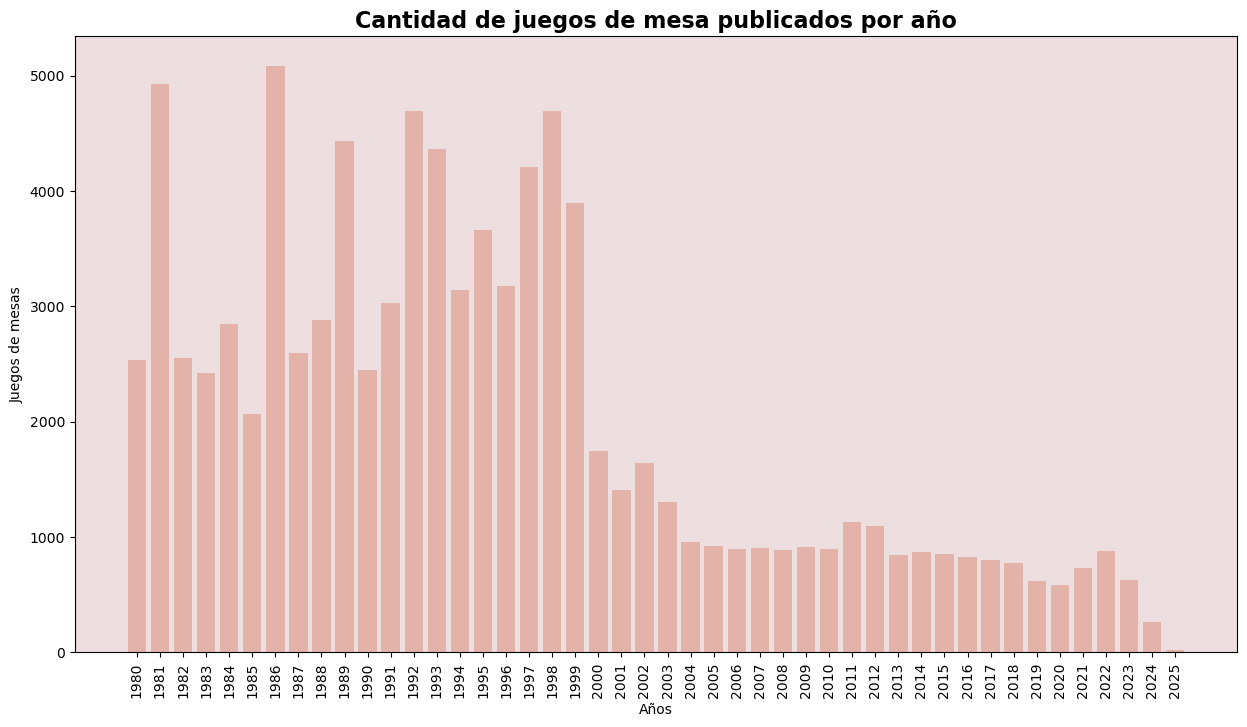

In [6]:
#Filtramos los años por los rangos de años que nos piden.
año_publicación = año_publicación[(año_publicación > 1979) & (año_publicación < 2026)]
#Sacamos cuántos juegos hay por años
juegos_por_años = año_publicación.value_counts().sort_index()
#Primero asigne las variables
valor_x = año_publicación.unique()
valor_y = año_publicación.value_counts().tolist()
#Para poder graficar me guíe de estas dos pagínas: https://medium.com/@gamoles/4-tips-para-dar-formato-al-texto-en-matplotlib-fa6c328ee9ab
#https://medium.com/ironhack/data-visualization-con-pandas-y-matplotlib-7f1358be6764, el primer link me ayudo más en el tema del diseño, ya que quería que se viera más bonito
#Y el segundo link, me ayudó a poder tener una idea más clara y mejor de como graficarlo
plt.figure(figsize=(15,8))
plt.bar(valor_x,valor_y, color = '#E3B3A9')
plt.title('Cantidad de juegos de mesa publicados por año',fontsize = 16, fontweight = 'bold')
ax = plt.subplot()
ax.set_xticks(valor_x)
ax.set_xticklabels(valor_x,rotation = 90)
ax.set_xlabel("Años")
ax.set_ylabel("Juegos de mesas")
ax.set_facecolor('#EDDEE0')



🔍Podemos ver que, a lo largo de los años desde 1980 hasta 2019, la tendencia de los juegos de mesa ha ido aumentando, alcanzando su punto máximo en 2019. Luego, a partir de 2019, ha ido disminuyendo. Se puede apreciar que el decrecimiento no mayor desde 2019 hasta 2022, pero vemos un gran decremiento en 2023 y 2024, y esta gran disminución continúa hasta el día de hoy.📈

**c) (0.5 pts)** ¿Entre qué años hubo un mayor aumento de publicación de juegos de mesa según los registros de BGG?

In [ ]:
#Calculamos la diferencia entre los años, a través de la función diff()
diferencia_años = juegos_por_años.diff()
#Ordenamos de mayor a menor los años donde se ven más aumentos y así encontrar los mayores aumentos
diferencia_años = diferencia_años.sort_values(ascending=False)
#Vemos los primeros 5 aumentos que son los cuales se ve un mayor aumento en comparación a las demás
mayor_aumento = diferencia_años.head()
#Por ultimo quise que se viera más bonita la tabla así que la pase a DataFrame y le pusimos un nombre
tabla = mayor_aumento.to_frame(name='Aumentos de publicaciones')
print(f"Podemos ver los top 5 años con más aumento de publicaciones de juegos y cuáles fueron sus valores de aumento")
tabla

Podemos ver los top 5 años con más aumento de publicaciones de juegos y cuáles fueron sus valores de aumento


,Aumentos de publicaciones
year,
2014,484
2019,395
2005,384
2018,330
2004,322


### 3.3 Análisis de duración y complejidad (1.5 puntos)

Si bien hay muchas posibles características que podemos explorar para los juegos de mesa, esta vez nos centraremos en el tiempo de juego y la complejidad. En esta sección queremos comprender si se ha modificado notablemente la duración promedio y la percepción de complejidad de los juegos de mesa a través de los años.

**a) (0.3 pts)** Inspecciones y filtre los datos que tengan valores válidos para: tiempo mínimo de juego, tiempo máximo de juego y complejidad. En el caso de que existan "outliers", puede descartarlos, cosiderando un rango razonable para las variables anteriores. Justifique su desición.

In [8]:
#Definimos los datos para que sea más facil de manejar, ya que me sirve manejar los tiempos con datos enteros
tiempo_mínimo = data['min_time'].astype('Int64')
tiempo_máximo = data['max_time'].astype('Int64')
complejidad = data['complexity']
#Luego ocupamos la función concat(), para combinar los DataFrames de tiempos y complejidad
datos = pd.concat([tiempo_mínimo,tiempo_máximo,complejidad], axis=1)
#Limpiamos para que nos queden solo valores no nulos, a través de la función dropna()
datos = datos.dropna()
print(datos.describe())
#Por último filtre por los rangos válidos que encontre razonables, los cuales se explicarán abajo del codigo.
datos = datos[(datos['min_time'] >= 10) & (datos['min_time'] <= 120) & (datos['max_time'] >= 10) & (datos['max_time'] <= 360) & (datos['complexity'] >= 1) & (datos['complexity'] <= 5)]
#Como parte de guía para elegir los rangos ocupe la función describe(), que me permitía ver los quartiles para tomar una desición

         min_time    max_time    complexity
count     43454.0     43454.0  43454.000000
mean    58.699291   87.706218      1.904462
std    433.832809  733.971386      0.823448
min           1.0         1.0      1.000000
25%          20.0        20.0      1.000000
50%          30.0        45.0      1.972950
75%          60.0        90.0      2.408875
max       60120.0     84000.0      5.000000


La razón por la cual elegí estos rangos de valores válidos ya que a partir de la función describe(), vi los diferentes valores de los cuartiles promedios, y a partir de eso me guie me sacar los rangos, puse tiempo mínimo 10 minutos, ya que igual depende del juego cuánto tiempo dure, pero encuentro que un buen tiempo minímo e igual sabiendo que recién el 25% es de 20 minutos, decidí poner 10 minutos como minímo y 360 como máximo, ya que igual suele pasar que ciertos juegos son más largos aunque viendo el cuartil 75% es 60 minutos como mínimo y maxímo son 90 minutos, de todas maneras quise dejar el máximo 360 minutos.

**b) (0.2 pts)** Veremos ahora si ha cambiado la duración promedio de los juegos de mesa en nuestro rango de años seleccionado. Primero, cree una nueva columna `avg_time` en el dataset con la duración promedio supuesta para cada juego.

In [9]:
#Sacamos el promedio de los datos según el rango de los años seleccionados de los tiempos de juegos, que en este caso eran tiempo mínimo y tiempo máximo
tiempo_promedio = datos[['min_time','max_time']].mean(axis=1)
#Creamos la columna pedida
avg_time = [tiempo_promedio]
#Lo guardamos en el DataFrame la nueva columna
df_unificado['avg_time'] = tiempo_promedio
df_unificado.to_csv("Data/data_unificado.csv",index=False)
df_unificado.head()


,bgg_id,name,year,min_players,max_players,min_players_rec,max_players_rec,min_players_best,max_players_best,min_age,...,wikidata_id,wikipedia_id,game_type,designer,artist,mechanic,category,family,publisher,avg_time
0,1,Die Macher,1986.0,3.0,5.0,4.0,5.0,5.0,5.0,14.0,...,NaN,NaN,Strategy Game,Karl-Heinz Schmiel,NaN,NaN,NaN,NaN,NaN,<NA>
1,2,Dragonmaster,1981.0,3.0,4.0,3.0,4.0,3.0,4.0,12.0,...,NaN,NaN,Strategy Game,"G. W. ""Jerry"" D'Arcey",Bob Pepper,Trick-taking,NaN,NaN,NaN,30.0
2,3,Samurai,1998.0,2.0,4.0,2.0,4.0,3.0,3.0,10.0,...,NaN,NaN,Strategy Game,Reiner Knizia,Franz Vohwinkel,NaN,NaN,NaN,NaN,45.0
3,4,Tal der Könige,1992.0,2.0,4.0,2.0,4.0,2.0,4.0,12.0,...,NaN,NaN,Strategy Game,Christian Beierer,Thomas di Paolo,NaN,Ancient,NaN,KOSMOS,60.0
4,5,Acquire,1964.0,2.0,6.0,3.0,6.0,4.0,4.0,12.0,...,NaN,NaN,Strategy Game,Sid Sackson,NaN,NaN,NaN,NaN,NaN,90.0


**c) (0.5 pts)** Grafique la duración promedio de juegos al año entre 1980 y 2025. ¿Existe alguna tendencia? Asegúrese de colocar las unidades correspondientes en sus ejes si es necesario. Comente sus resultados.

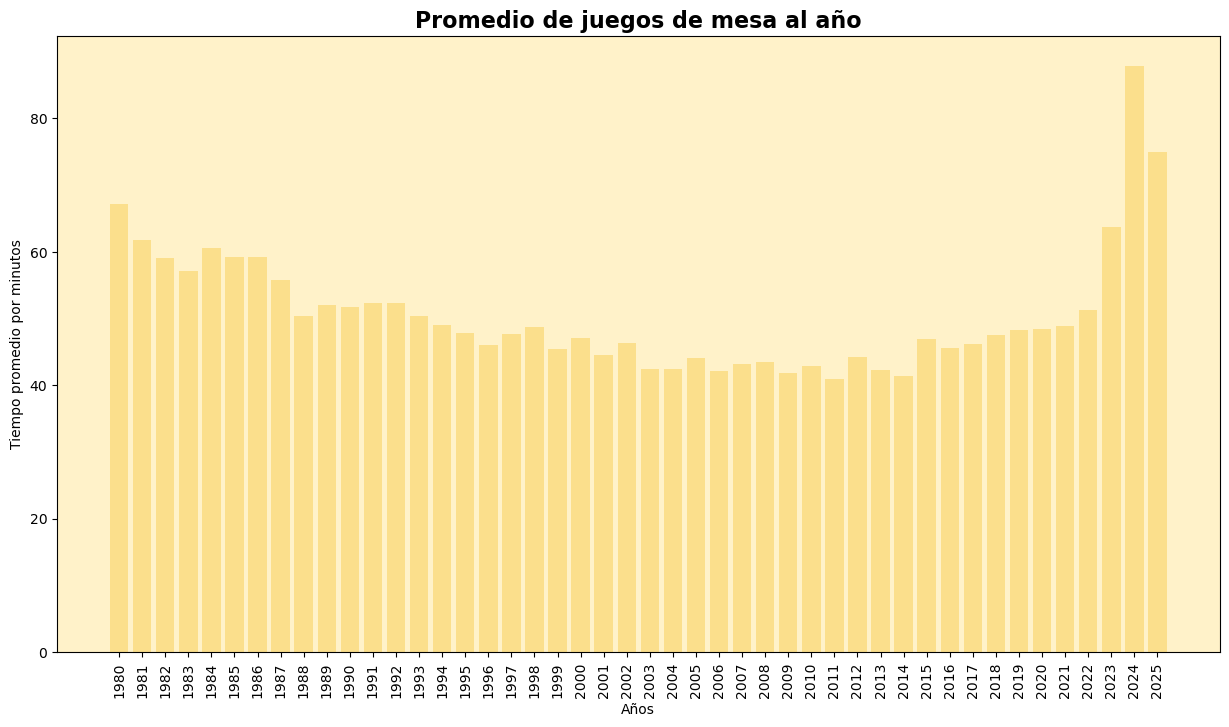

In [10]:
#Primero sacamos el promedio de juego por los años, a través de la función groupby() juntamos los datos para poder calcular el promedio luego a través de la función mean()
años_promedio = df_unificado.groupby('year')['avg_time'].mean().reset_index()
#Luego lo filtramos para el rango de años que nos piden
años_promedio = años_promedio[(años_promedio['year'] > 1979) & (años_promedio['year'] < 2026)]
#Volvemos a asignar las variables para el eje x y eje y
valor_x = años_promedio['year'].astype('Int64')
valor_y = años_promedio['avg_time']
#Grafico de la misma forma la cual lo realice arriba, solo que cambie los colores
plt.figure(figsize=(15,8))
ax = plt.subplot()
plt.bar(valor_x, valor_y, color = '#FBDF8C')
ax.set_title('Promedio de juegos de mesa al año',fontsize = 16, fontweight = 'bold')
ax.set_xticks(valor_x)
ax.set_xticklabels(valor_x, rotation = 90)
ax.set_xlabel("Años")
ax.set_ylabel("Tiempo promedio por minutos")
ax.set_facecolor('#FFF2C9')
plt.show()


No encuentro que haya alguna tendencia, sino que se mantiene el promedio más que nada a excepción de los últimos años 2023 y 2024, ya que en esos años se ve un aumento notable de en los minutos promedios de los juegos de mesas. Me imagino que puede ser que a medida que vamos avanzando en los años se van creando los juegos de mesas y a la vez aumentando sus dificultades por lo que es normal que haya un aumento en estos tiempos promedios.

**d) (0.5 pts)** Nos interesa saber si los juegos de mesa recientes son más complejos que aquellos publicados antes de los 2000. BoardGameGeek permite evaluar la complejidad (o "weight") de un juego en una escala de 1 a 5, siendo 1 un juego "liviano" o fácil de entender, y 5 un juego "pesado" o complejo. Primero, seleccione los juegos que han sido evaluados por al menos 100 usuarios. Luego grafique la complejidad promedio de los juegos según año. Responda: ¿ha cambiado la percepción de complejidad entre juegos entre 1980 y la actualidad?

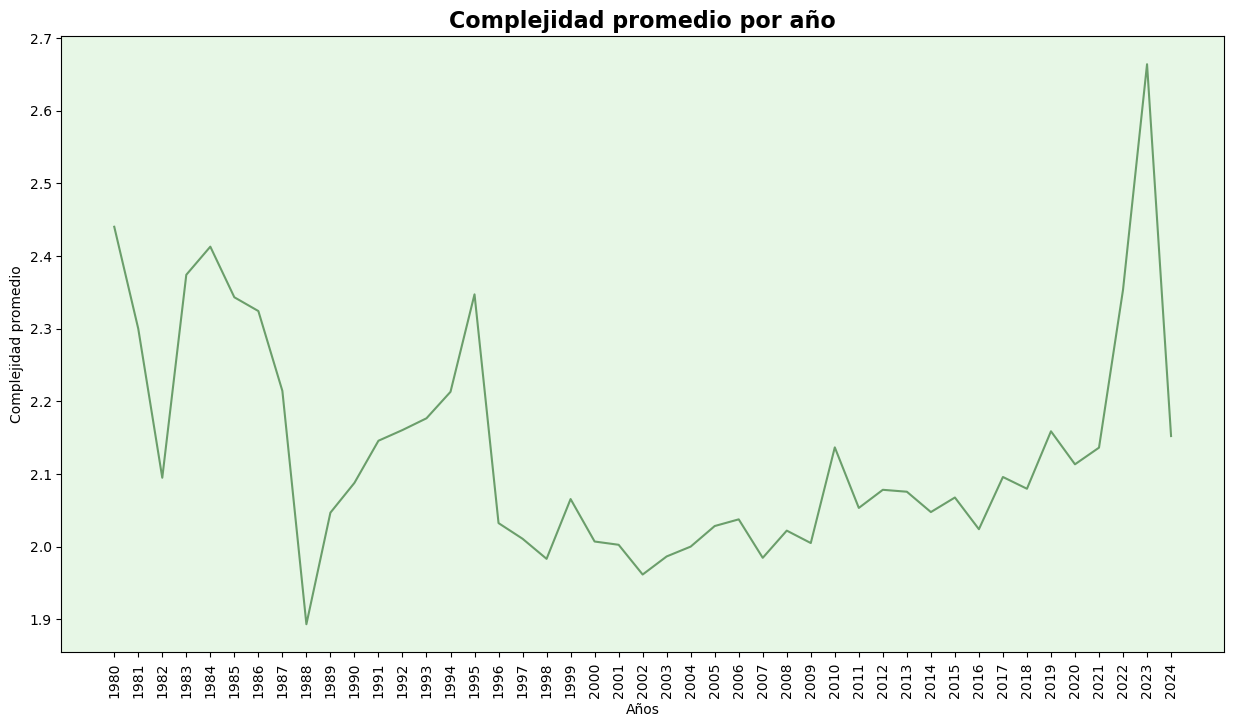

In [11]:
#Primero filtramos la condición de que sean al menos 100 usuarios que hayan evaluado los juegos 
datos= df_unificado[df_unificado['num_votes'] >= 100]
#Sacamos el promedio de la complejidad a través de los años
promedio_complejidad = datos.groupby('year')['complexity'].mean().reset_index()
#Filtramos por los años, los cuales piden.
promedio_complejidad = promedio_complejidad[(promedio_complejidad['year'] >= 1980) & (promedio_complejidad['year'] <= 2025)]
#Asignamos las variables de los ejes.
valor_x = promedio_complejidad['year'].astype('Int64')
valor_y = promedio_complejidad['complexity']
#Por último graficamos igual que las anteriores veces solo que ahora en vez de grafico de barra, es un grafico de linea, el único cambio fue el plt.plot y los colores.
plt.figure(figsize=(15,8))
ax = plt.subplot()
plt.plot(valor_x, valor_y, color='#6B9E6B')
ax.set_title('Complejidad promedio por año', fontsize=16, fontweight='bold')
ax.set_xticks(valor_x)
ax.set_xticklabels(valor_x, rotation=90)
ax.set_xlabel("Años")
ax.set_ylabel("Complejidad promedio")
ax.set_facecolor('#E7F7E6')
plt.show()

A partir de lo que se puede apreciar en el grafico, podemos ver que se produce una variación significativa a través de los años. Podemos notar que el peak de complejidad de los juegos de mesa fue  en el año 2023, y el mínimo se puede registrar en el año 1988. En general se aprecian cambios en la complejidad a lo largo de estos años, se ve que hay un periodo donde esta complejidad no suele cambiar tan radicalmente que es en el rango de los años: 1998-2021

### 3.4 Análisis de categorías comunes (2 puntos)

Existe una gran diversidad de categorías de juegos de mesa. Ahora nos concentraremos en un grupo específico de ellas, con el fin de analizar cómo a cambiado la cantidad de juegos de estas clases desde 1980 hasta hoy.

**a) (0.7 pts)** ¿Cuáles son las 5 categorías más comunes en los juegos del dataset? Muestre la cantidad de juegos que hay de cada una. Puede graficar estos valores, o bien, entregar un DataFrame con sus valores.

In [12]:
#Para poder sacar las 5 categorías más comunes, primero seleccione su columna y aplique la función value_counts()
#Ya que saca la frecuencia de cuantas veces ha sido seleecionada tal categoría, a partir de eso, y las ordena por defecto de mayor a menor.
# saque las top 5 categorías a través de la función head() y le agregue el 5 adentro, ya que quiero los primeros 5
categorias = df_unificado['category'].value_counts()
top_5_categorias = categorias.head(5)
#Lo pasamos a un DataFrame
categorias_comunes = pd.DataFrame(top_5_categorias)
categorias_comunes


,count
category,
Abstract Strategy,4896
Card Game,4829
Children's Game,2022
Sports,1455
Party Game,1439


**b) (0.3 pts)** Para cada una de estas 5 categorías, cree un DataFrame que contenga la cantidad de juegos en el dataset según año. Luego junte estos DataFrames en uno solo con los atributos de "Año", "Categoría" y "Cantidad".

In [13]:
#Cree DataFrame por separado de las 5 categorías diferentes, ocupe la función groupby para poder añadir lo que necesitaba que era el año y la cantidad
df_strategy = df_unificado[df_unificado['category'] == 'Abstract Strategy']
df_strategy = df_strategy.groupby('year').size().reset_index(name='count')
df_strategy['category'] = 'Abstract Strategy'

df_card = df_unificado[df_unificado['category'] == 'Card Game']
df_card = df_card.groupby('year').size().reset_index(name='count')
df_card['category'] = 'Card Game'

df_children = df_unificado[df_unificado['category'] == "Children's Game"]
df_children = df_children.groupby('year').size().reset_index(name='count')
df_children['category'] = "Children's Game"

df_sports = df_unificado[df_unificado['category'] == 'Sports']
df_sports = df_sports.groupby('year').size().reset_index(name='count')
df_sports['category'] = 'Sports'

df_party = df_unificado[df_unificado['category'] == 'Party Game']
df_party = df_party.groupby('year').size().reset_index(name='count')
df_party['category'] = 'Party Game'

#A través de la función concat() uní los DataFrames creados de las categorías para dejarlo en uno solo
df_categorias = pd.concat([df_strategy,df_card,df_children,df_sports,df_party])
#Luego sentí correspondiente filtrar que el año sea mayor a 1980 un poco en el contexto de las preguntas y que aparecian años en negativos.
df_categorias= df_categorias[df_categorias['year'] >= 1980]
#Pasamos los años a números enteros porque devolvia float
df_categorias['year'] = df_categorias['year'].astype('Int64')
#Ocupé la función pivot(), porque me imprimía mal la tabla, ya que me imprimía por año una categoría, y quería que me mostrara las 5 categorías y su cantidad por cada año
#Por lo que averigue en el libro "Phyton for Data Analysis" paginas 276-277 entonces me guie en el libro ya que no me imprimía como yo queria que se viera y ocupar
#  esa función ayudo a que más que nada que se viera como tabla de largo, se viera mas ancha y mostrara todas las categerías de uno a uno y  la función fillna() la ocupe para cuando no hubiera un valor, pusiera automaticamente un 0.
df_final = df_categorias.pivot(index='year', columns='category', values='count').fillna(0)

#Tenia los datos en float asi que los pase a números enteros a través de la función astype(), no funciono para la columna años, por eso mismo tuve que pasarlo arriba
#ya que se considera como indice la columna año, entonces cambia a todos a números enteros menos el indice.
df_final = df_final.astype('Int64')

df_final

category,Abstract Strategy,Card Game,Children's Game,Party Game,Sports
year,,,,,
1980,34,6,8,3,28
1981,37,7,15,0,12
1982,57,14,4,1,11
1983,51,24,10,2,13
1984,47,12,19,2,16
1985,66,11,18,9,28
1986,59,16,13,8,24
1987,61,14,13,12,27
1988,34,16,23,17,26


**c) (1 pto)** Grafique, en un solo gráfico y con distintos colores, la cantidad de juegos por año según categoría. Preocúpese de ponerle etiquetas al gráfico para identificar cada categoría y una leyenda donde se muestre cada una. Comente: ¿ha habido un cambio entre los juegos más comunes en los años 80 y hoy?


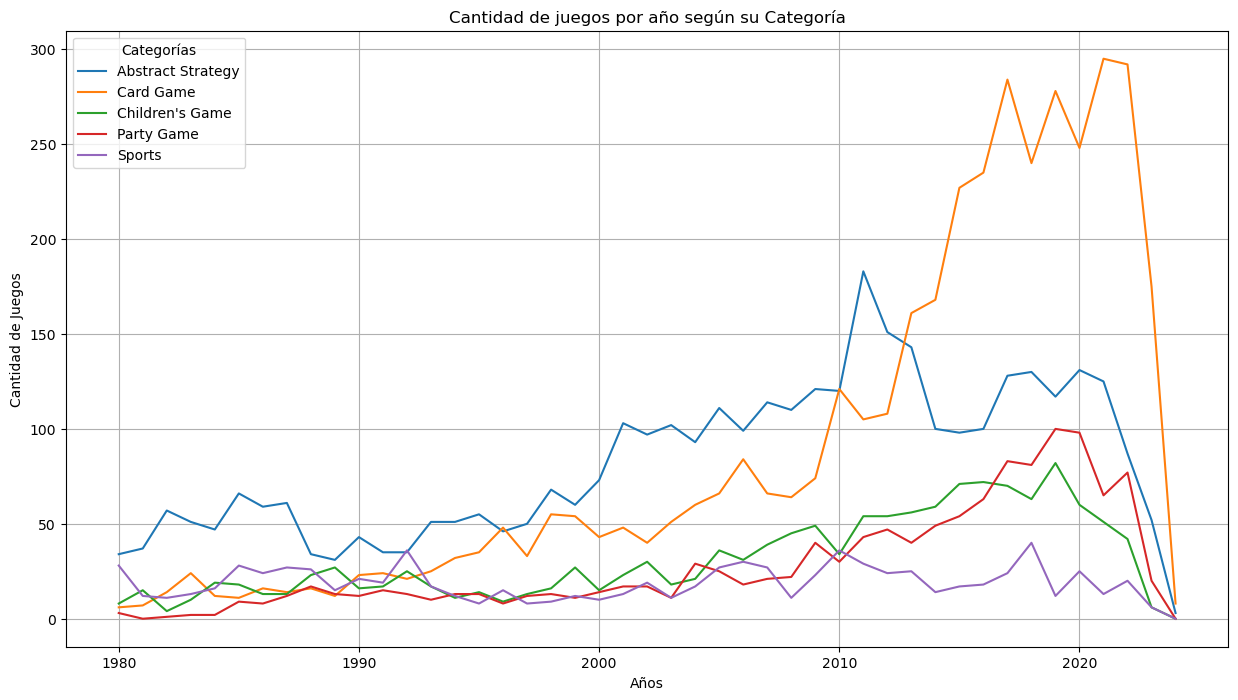

In [ ]:
#Para graficar, como ya tengo todos los datos que necesito en el DataFrame que lo llame dt_final lo grafique directamente, así que lo único aparte que hice 
#fue escribir los titulos para sus respectivos ejes
df_final.plot(figsize=(15,8))
plt.title("Cantidad de juegos por año según su Categoría")
plt.xlabel("Años")
plt.ylabel("Cantidad de Juegos")
plt.legend(title="Categorías")
#Para ocupar está función me guíe por el libro "Python for Data Analysis" y vi esa función en la pagína 299, más que nada la puse para que se viera un poco más ordenado con las cuadriculas.
plt.grid()
plt.show()

Si se puede ver que a principios de los años 80 había una notoria diferencia de juegos, ya que más que nada han eran juegos de estrategia el que lideraba las cantidades de juegos, pero en el último tiempo se puede apreciar un aumento muy grande en los juegos de cartas, inclusive llegando a un peak de juegos más alto que los juegos de estrategia que en sus tiempos eran muy populares, pero aún así siguen estando en un top, ya que estos se juegan más que las otras 3 categorías. En conclusión si ha habido un cambio, ya que se popularizo más los juegos de cartas pero aún asi sigue habiendo una tendencia mayor por los juegos de estrategia.

### 3.5 Análisis Crítico (Bono +0.5 puntos)

¿Qué limitaciones o problemas encontraste en los datos?

Unos de mis mayores problemas que me sucedio al hacer la Tarea era de que al principio no me dejaba pasar de string a entero, me los dejaba en float, y de hecho la mayoría de las veces tuve que volver a pasarlos a enteros.

También me paso que algunos datos eran nulos, entonces no tenían la información completa, ya que faltaban datos y no sabía muy bien como manejarlos, pero a medida de que iba avanzando en la tarea fui conociendo ciertas funciones que pueden facilitar mucho el hecho de tener datos nulos/faltantes. Por ejemplo uno de los últimos que ocupé fue fillna(), ya que ahí solo reemplace por 0 los datos que eran nulos o ocupar la función dropna() que me sirvió también para limpiar los datos nulos.